# Pivot in pandas

## Import libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## what is pivot?
In Pandas, ```.pivot()``` function is used to reshape your DataFrame by turning unique values from one column into new columns, while reorganizing the data around an index. <br>
syntax : ```DataFrame.pivot(index=None, columns=None, values=None)``` <br>
**Parameters** : <br>
- index : column(s) to use as row labels
- columns : column whose unique values will become new columns
- values : column whose values will fill new table (cells)'
## Let's look at an example:

In [2]:
#generate a sample data for pivot demonstration
data = {
    "city": ["mumbai", "mumbai", "delhi", "delhi", "lucknow", "lucknow"],
    "date": ["2025-08-01", "2025-08-02", "2025-08-01", "2025-08-02", "2025-08-01", "2025-08-02"],
    "temperature": [30, 32, 40, 42, 35, 37]
}

In [3]:
df_pivot = pd.DataFrame(data)
df_pivot

,city,date,temperature
0,mumbai,2025-08-01,30
1,mumbai,2025-08-02,32
2,delhi,2025-08-01,40
3,delhi,2025-08-02,42
4,lucknow,2025-08-01,35
5,lucknow,2025-08-02,37


In [4]:
pivoted_df = df_pivot.pivot(index="date",columns="city",values="temperature")
pivoted_df

city,delhi,lucknow,mumbai
date,,,
2025-08-01,40,35,30
2025-08-02,42,37,32


### Explaination:
- ```date``` became the index (rows)
- ```city``` values (```mumbai```, ```delhi```, ```lucknow```) became new columns.
- ```temperature``` values filled the table.
<br>
So instead of having a long format data (row-wise) now we have a wide format table where each city's temperature is in its own column.

### Limitations of ```pivot```
1. It doen't allow duplicates for the combination of ```index``` + ```columns```
   - If you have duplicates, Pandas will throw an error.
   - Exmple : If ```mumbai``` city has two temperature recorded on the same date then ```pivot``` won't know which one to use.
   - In that case, you should use ```pivot_table()``` instead, because it allows aggregation (mean,sum,etc...)
2. Works best with clean and tidy data where one combination of index and column is unique.



## Senarios where reshaping dataFrame using ```.pivot()``` function might help
Pivoting (reshaping) shines whenever you need to turn "long and tidy" rows into a "wide" table so each category gets its own column. That unlocks plotting, reporting ML feature building, and matrix - like analysis.

### 1. Time-series by category (easy plotting and comparision)
Goal: One line per city on a single chart.

In [5]:
df_ex1 = pd.DataFrame({
    "date": ["2025-01-01","2025-01-01","2025-01-02","2025-01-02"],
    "city": ["mumbai","delhi","mumbai","delhi"],
    "temp": [30, 40, 32, 42]
})

wide_ex1 = df_ex1.pivot(index="date",columns="city",values="temp")
wide_ex1

city,delhi,mumbai
date,,
2025-01-01,40,30
2025-01-02,42,32


**Why pivot helps :** Many plotting functions expect one column per series. After pivot, ```wide.plot()``` draws both city lines immidiately.

#### Example code to explain ```Why pivot helps : Many plotting functions expect one column per series. After pivot, wide.plot() draws both city lines immidiately.```

In [6]:
# generate data simulating a dataFrame having multiple city data related to temperature by date.
india_weather_temperature = {
    "date": pd.date_range(start="2025-08-01", periods=5).tolist() * 3,
    "city": ["mumbai"] * 5 + ["lucknow"] * 5 + ["delhi"] * 5,
    "Temperature": [
        # Mumbai (warm and stable)
        29, 30, 31, 28, 29,
        # Lucknow (hotter variation)
        34, 36, 33, 35, 37,
        # Delhi (very hot summers)
        38, 40, 39, 41, 42
    ],
}

# create a dataFrame out of this data
india_weather_temperature_df_ex2 = pd.DataFrame(india_weather_temperature)
india_weather_temperature_df_ex2

,date,city,Temperature
0,2025-08-01,mumbai,29
1,2025-08-02,mumbai,30
2,2025-08-03,mumbai,31
3,2025-08-04,mumbai,28
4,2025-08-05,mumbai,29
5,2025-08-01,lucknow,34
6,2025-08-02,lucknow,36
7,2025-08-03,lucknow,33
8,2025-08-04,lucknow,35
9,2025-08-05,lucknow,37


Let's plot a graph and see how it looks

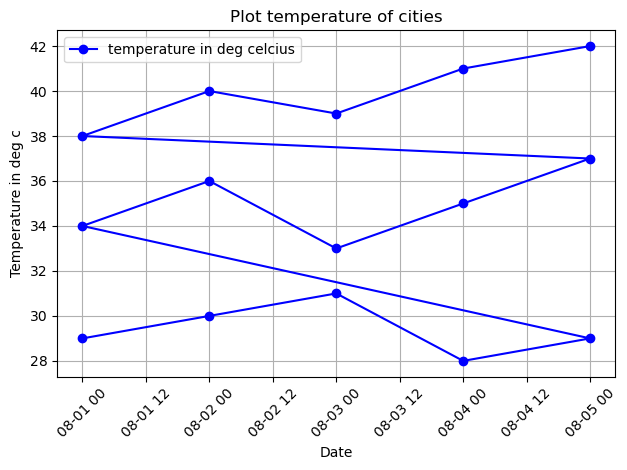

In [7]:
plt.title("Plot temperature of cities")
plt.plot(india_weather_temperature_df_ex2["date"],india_weather_temperature_df_ex2["Temperature"],linestyle="-",marker="o",color="blue",label="temperature in deg celcius")
plt.xlabel("Date")
plt.ylabel("Temperature in deg c")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

As you can see It's not very helpful because it plotted the the temperatures for all the cities by date and hence we can't make out which temperature data points belongs to which city.

**Solution**:
1. Use groupby to group the temperatures by cities and then plot it using pyplot in the graph manually using a forloop
2. Privot (reshape) the dataFrame in a way that each city has its own column instead of the rows.

#### Solution method 1 : Use groupby to group the temperatures by cities and then plot it using pyplot in the graph manually using a forloop

In [8]:
india_weather_temperature_df_ex2

,date,city,Temperature
0,2025-08-01,mumbai,29
1,2025-08-02,mumbai,30
2,2025-08-03,mumbai,31
3,2025-08-04,mumbai,28
4,2025-08-05,mumbai,29
5,2025-08-01,lucknow,34
6,2025-08-02,lucknow,36
7,2025-08-03,lucknow,33
8,2025-08-04,lucknow,35
9,2025-08-05,lucknow,37


In [9]:
# group the temperature based on cities 
india_weather_temperature_df_ex2_groupby = india_weather_temperature_df_ex2.groupby("city")
india_weather_temperature_df_ex2_groupby

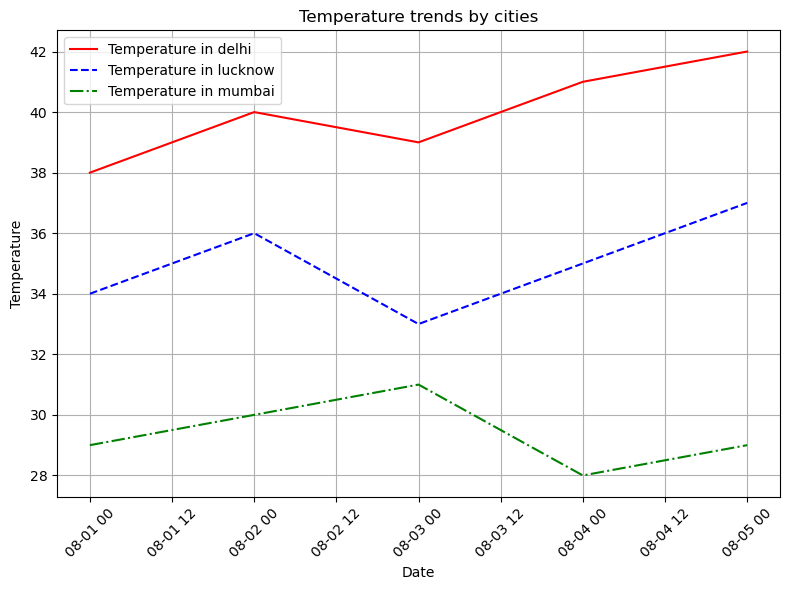

In [10]:
import itertools

linestyle_list = ["-", "--", "-."]
color_list = ["red","blue","green"]

linestyle_cycle = itertools.cycle(linestyle_list)
color_cycle = itertools.cycle(color_list)

plt.figure(figsize=(8,6))
plt.title("Temperature trends by cities")
for city, city_df in india_weather_temperature_df_ex2_groupby:
    plt.plot(city_df["date"],city_df["Temperature"],label=f"Temperature in {city}",linestyle=next(linestyle_cycle),color=next(color_cycle))
plt.grid(True)
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Temperature")
plt.tight_layout()
plt.legend()
plt.show()

#### Using barcharts 

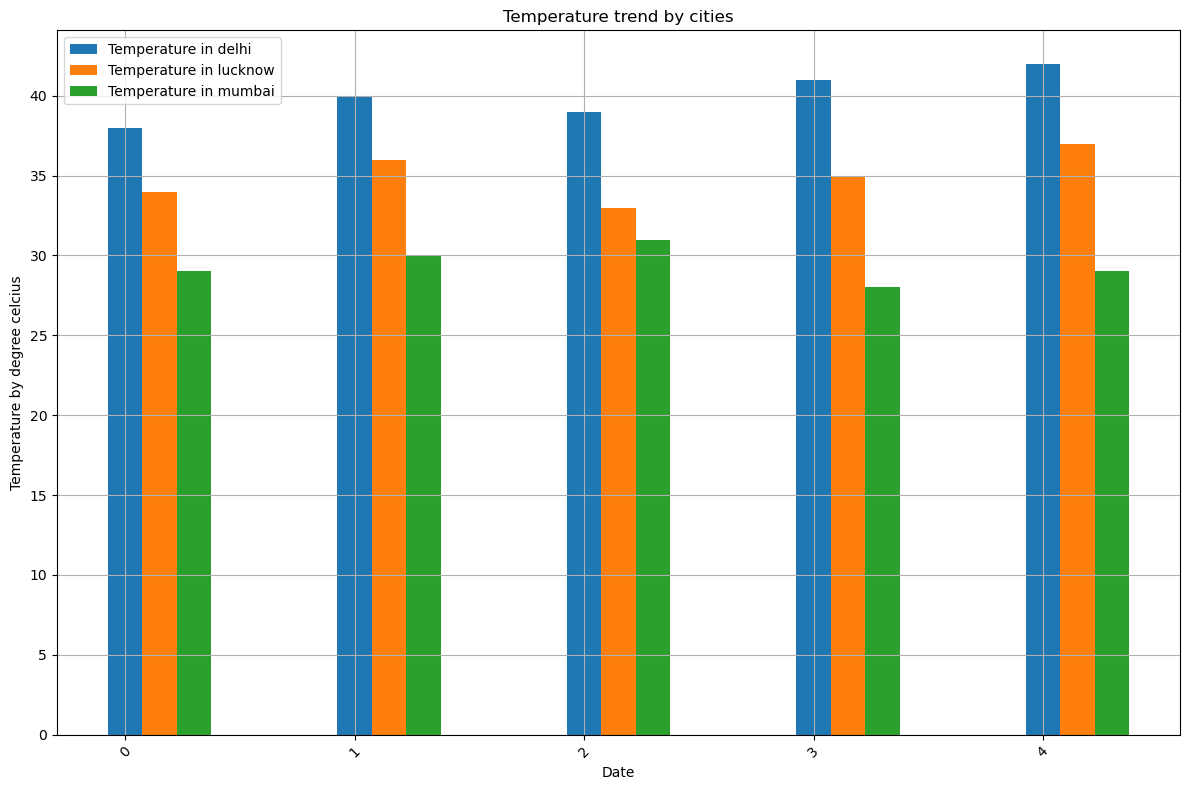

In [11]:
dates = sorted(india_weather_temperature_df_ex2["date"].unique())
x = np.arange(len(dates))
width = 0.15

plt.figure(figsize=(12,8))
for i, (city,city_df) in enumerate(india_weather_temperature_df_ex2_groupby):
    plt.bar(
        x + i * width,
        city_df["Temperature"],
        width=width,
        label=f"Temperature in {city}"
    )
plt.title("Temperature trend by cities")
plt.xlabel("Date")
plt.ylabel("Temperature by degree celcius")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

#### Solution method 2: Privot (reshape) the dataFrame in a way that each city has its own column instead of the rows.

In [12]:
india_weather_temperature_df_ex2

,date,city,Temperature
0,2025-08-01,mumbai,29
1,2025-08-02,mumbai,30
2,2025-08-03,mumbai,31
3,2025-08-04,mumbai,28
4,2025-08-05,mumbai,29
5,2025-08-01,lucknow,34
6,2025-08-02,lucknow,36
7,2025-08-03,lucknow,33
8,2025-08-04,lucknow,35
9,2025-08-05,lucknow,37


In [13]:
wide_df4 = india_weather_temperature_df_ex2.pivot(index="date",columns="city",values="Temperature")
wide_df4

city,delhi,lucknow,mumbai
date,,,
2025-08-01,38,34,29
2025-08-02,40,36,30
2025-08-03,39,33,31
2025-08-04,41,35,28
2025-08-05,42,37,29


Now each city has it's own column

Let's plot in graph after the pivot operation now

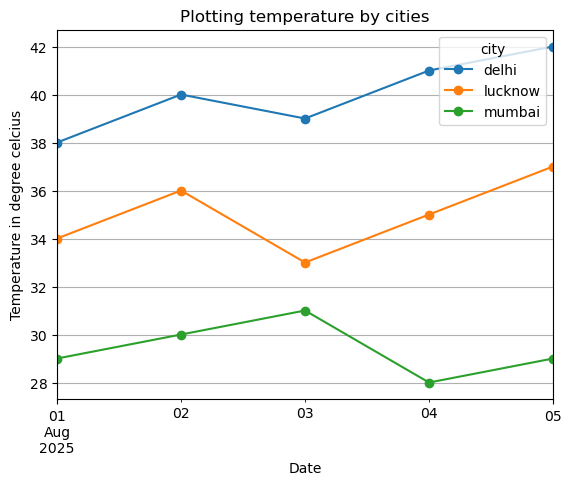

In [14]:
wide_df4.plot(marker="o",linestyle="-")
plt.title("Plotting temperature by cities")
plt.ylabel("Temperature in degree celcius")
plt.grid(True)
plt.xlabel("Date")
plt.show()

As you can see there 
- colors are automatically cycled but incase when we used the groupby method we had to cycle through colors manually using ```itertools```
- And the results are the same as what I have achieved when we applied groupby method to plot temperature trends by cities
- The line of code also got reduced

<br>

Pivoting (reshaping) dataFrames only works well when data is clean and tidy reshaping won't work if the data is not clean. 

<br>

**Why pivot helps?** <br>
Most plotting functions like (```.plot()```, ```matplotlib```, ```seaborn.heatmap```) treat each numeric columns as a separate seires.
- In long format, all temps are in one columns : You need grouping logic.
- In wide format, each city is a column : ```.plot()``` automatically knows to draw one line per column.

### 2. Metric names to columns (dashboard/ KPI tables)
Goal: Daily KPIS in columns for easy reading/export. <br>
**What is KPI tables?** <br>
A KPI is a measurable value that indicates progress toward a goal. It means a **Key Performance Indicator table**. It's basically a structured way of tracking the most important metrics (KPIs) for a business, process or project.

In [15]:
# generate data 

# function to make sure the number of rows is divisible by the number elements in the metrics_list
def rows_must_be_divisible(number_of_rows,metrics_list):
    if not number_of_rows%len(metrics_list):
        return True
    else:
        False

# function to generate data for KPI
def generate_data_for_KPI(number_of_rows, metrics_list):
    if not rows_must_be_divisible(number_of_rows,metrics_list):
        raise ValueError(f"number of rows must be divisible by {len(metrics_list)}")
    n_rows = number_of_rows
    dates = pd.date_range("2025-01-01",periods = n_rows // 3 , freq="D")
    metrics = metrics_list

    data = {
        # repeat dates each for 3 matrics
        "date" : np.repeat(dates,3)[:n_rows],
        # cicle matrics
        "metrics" : metrics * (n_rows // 3) + metrics[:n_rows % 3],
        # random values
        "value" : np.random.randint(100,2000,size=n_rows)
    }
    return data 

#### Explaination : ```dates = pd.date_range("2025-01-01", periods = n_rows // 3 , freq="D")```
- ```pd.date_range``` : generates a sequence of dates
- ```2025-01-01``` : start date.
- ```periods = n_rows // 3``` : The number of dates generated
  - Here, ```n_rows // 3``` means integer division (divide ```n_rows``` by 3 and take only the whole number part)
  - Example: If ```n_rows = 44```, then ```44 // 4 = 15``` so it egenrates 14 dates accordingly
- ```freq="D"``` : frequency = daily, so the dates are consecutive days.

#### Explaination : ```"metrics" : metrics * (n_rows // 3) + metrics[:n_rows % 3]```
- This is building the ```"metrics"```column.
  - ```metrics``` : suppose it's ```["revenue", "users", "orders"]```.
  - ```metrics * (n_rows // 3)``` : repeats the whole list ```(n_rows // 3)``` times.
    - Example: If ```n_rows = 44``` , then ```n_rows // 4 = 14```.
    - So it repeats the list 14 times : 42 entries.
  - ```metrics[:n_rows % 3]``` : takes the remainder part
    - ```n_rows % 3``` is the leftover rows after making groups of 3.
    - Example : ```44 % 3 = 2```, so it takes the first 2 metrics : ```["revenue","users"]```

In [16]:
number_of_rows = 45
metrics_list = ["revenue","users","orders"]

# create dataFrame using the generated data
df_kpi = pd.DataFrame(generate_data_for_KPI(number_of_rows,metrics_list))
df_kpi

,date,metrics,value
0,2025-01-01,revenue,1298
1,2025-01-01,users,250
2,2025-01-01,orders,764
3,2025-01-02,revenue,1471
4,2025-01-02,users,291
5,2025-01-02,orders,1337
6,2025-01-03,revenue,520
7,2025-01-03,users,670
8,2025-01-03,orders,1003
9,2025-01-04,revenue,1832


#### Performing pivot (reshaping) operation on dataFrame

In [17]:
kpis = df_kpi.pivot(index="date",columns="metrics",values="value")
kpis

metrics,orders,revenue,users
date,,,
2025-01-01,764,1298,250
2025-01-02,1337,1471,291
2025-01-03,1003,520,670
2025-01-04,696,1832,1775
2025-01-05,1842,733,1931
2025-01-06,1197,1521,432
2025-01-07,374,374,814
2025-01-08,1579,1584,1195
2025-01-09,1974,636,654


#### **Easier to plot graphs**

#### Plot the data in a graph

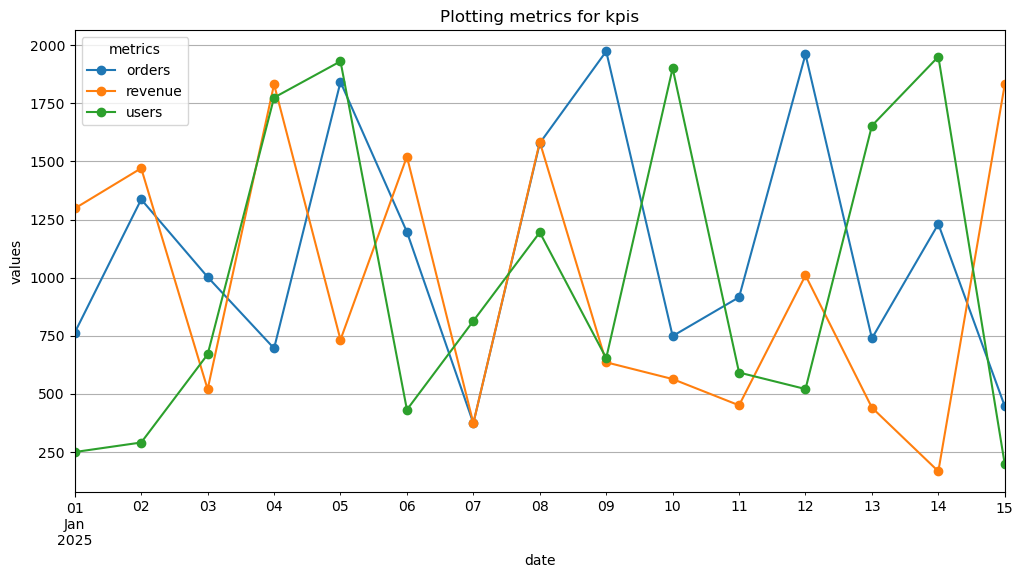

In [18]:
kpis.plot(marker="o",linestyle="-",figsize=(12,6))
plt.title("Plotting metrics for kpis")
plt.ylabel("values")
plt.xlabel("date")
plt.grid(True)
plt.show()

#### Plot bar graph instead

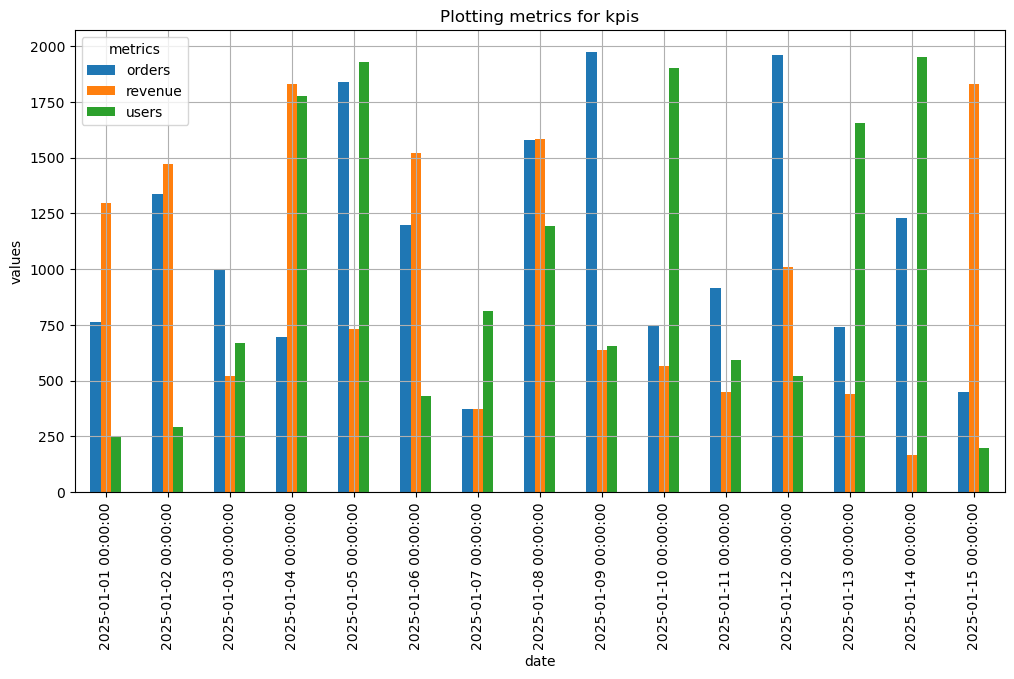

In [19]:
kpis.plot(kind="bar",figsize=(12,6))
plt.title("Plotting metrics for kpis")
plt.ylabel("values")
plt.xlabel("date")
plt.grid(True)
plt.show()

#### **Easier to calculate metrics**

In [20]:
kpis["ASP"] = kpis["revenue"]/kpis["orders"]
kpis

metrics,orders,revenue,users,ASP
date,,,,
2025-01-01,764,1298,250,1.698953
2025-01-02,1337,1471,291,1.100224
2025-01-03,1003,520,670,0.518445
2025-01-04,696,1832,1775,2.632184
2025-01-05,1842,733,1931,0.397937
2025-01-06,1197,1521,432,1.270677
2025-01-07,374,374,814,1.000000
2025-01-08,1579,1584,1195,1.003167
2025-01-09,1974,636,654,0.322188


Here ```ASP``` is Average Selling Price. 
- If you divide the total revenue by the number of orders recieved you will get the average selling price as a result
#### This goes to show that its easier to compute from long format dataFrame, because metrics are already in separate columns.

#### Plotting the graph to show average selling price

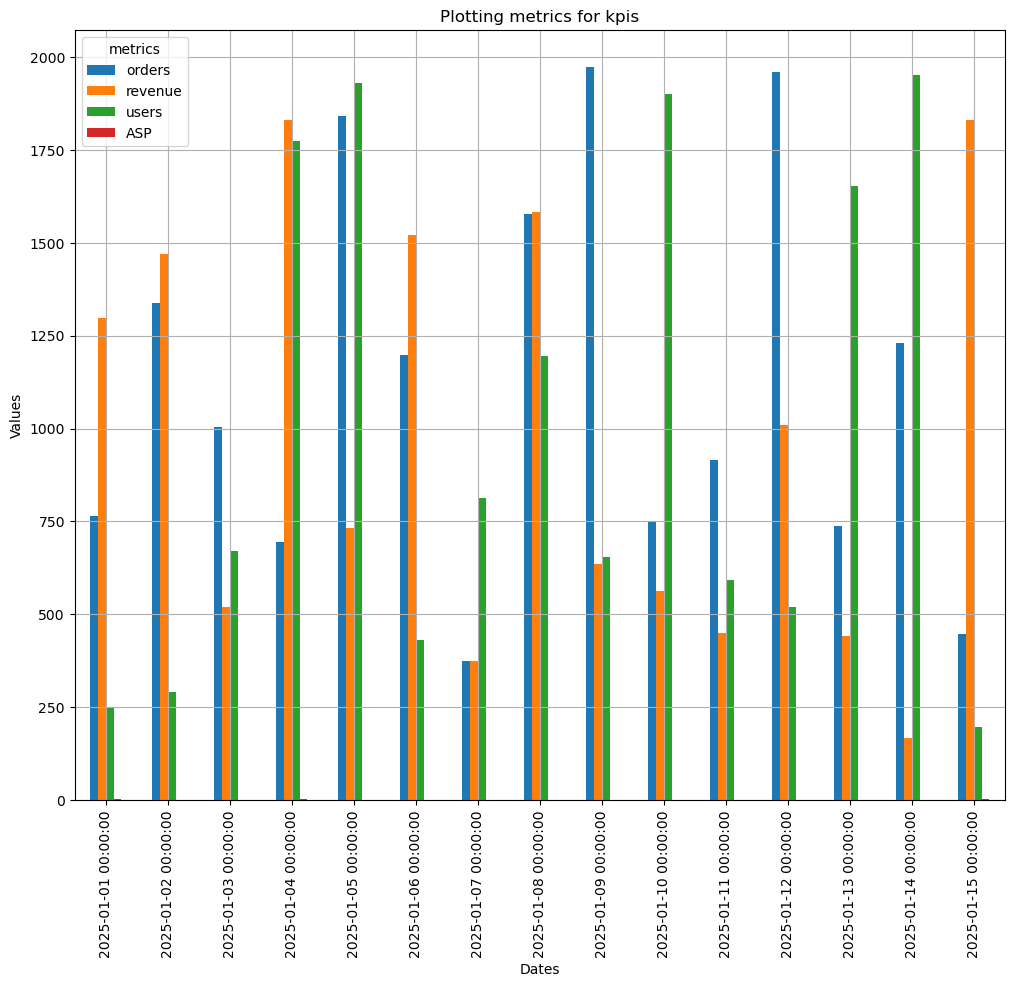

In [21]:
kpis.plot(kind="bar",figsize=(12,10))
plt.title("Plotting metrics for kpis")
plt.ylabel("Values")
plt.xlabel("Dates")
plt.grid(True)
plt.show()

#### So the ASP data bar doesn't show up even though it shows up in the graph's legend
The reason why ASP doesn’t show up in your bar chart even though it appears in the legend is because of scale mismatch.
#### Solution: 
Plot the ASP data separately 

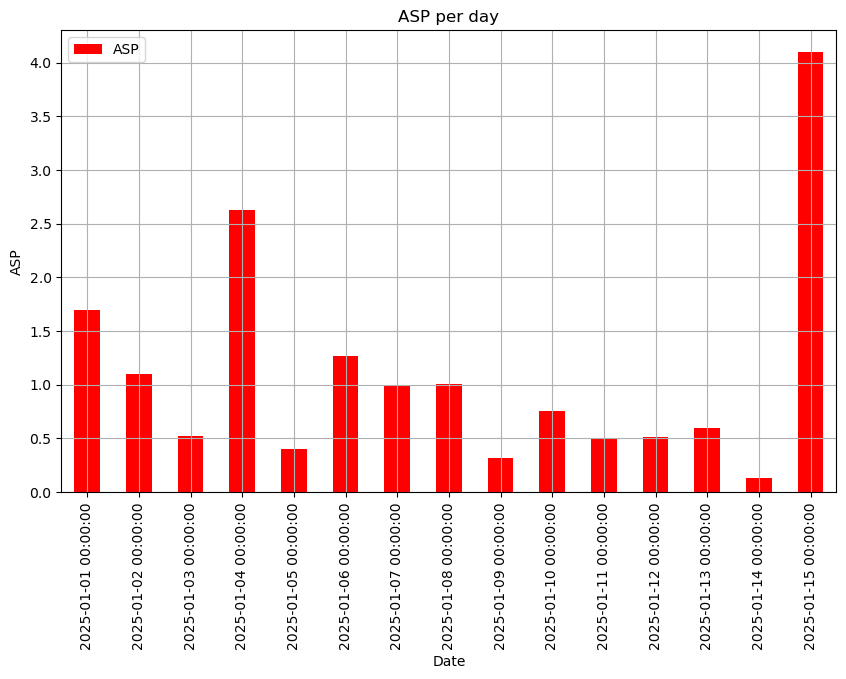

In [22]:
kpis["ASP"].plot(kind="bar",figsize=(10,6),color="red",legend=True)
plt.title("ASP per day")
plt.ylabel("ASP")
plt.xlabel("Date")
plt.grid(True)
plt.show()

Now the data in the ASP column is being shown correctly

### 3. Finance / Stock Market Data

#### import necessary libraries

In [54]:
import random 
from datetime import datetime , timedelta
from typing import List, Dict, Any
import itertools

#### Generate data

In [55]:
def generate_stockmarket_data(data:List[Dict[str,Any]]=None, stocks:List[str]=None, start_date:datetime=None) -> List[Dict[str,Any]]: 
    # Validate if the input provided is in correct type or not
    if not isinstance(data,list):
        raise TypeError("Data must be of type List of Dictionaries")
    if not isinstance(stocks,list):
        raise TypeError("Stocks must be of type List")
    if not isinstance(start_date,datetime):
        raise TypeError("start_date must be of type datetime object")
    
    # Checking if data is not present if not then raise ValueError
    if not data:
        raise ValueError("Initial data required!")
    if not stocks:
        raise ValueError("Company stock names required!")
    if not start_date:
        raise ValueError("Start Date required!")
    while len(data) < 30:
        for stock in stocks:
            if len(data) >= 30:
                break
            base_price = {"AAPL": 180, "MSFT": 340, "GOOG": 140, "AMZN": 130}[stock]
            price = base_price + random.randint(-5, 10)

            # Append row
            data.append({
                "date":start_date.strftime("%Y-%m-%d"),
                "stock":stock,
                "price":price
            })
            start_date += timedelta(days=1)

    return data

#### Create dataFrame from the generated stock data

In [56]:
# initial data
data = [
    {"date": "2025-01-01", "stock": "AAPL", "price": 185},
    {"date": "2025-01-01", "stock": "MSFT", "price": 350},
    {"date": "2025-01-02", "stock": "AAPL", "price": 187},
    {"date": "2025-01-02", "stock": "MSFT", "price": 355},
]
stocks = ["AAPL", "MSFT", "GOOG", "AMZN"]
start_date = datetime(2025, 1, 3)

# create dataFrame
stock_df_original = pd.DataFrame(generate_stockmarket_data(data,stocks,start_date))
stock_df_original

,date,stock,price
0,2025-01-01,AAPL,185
1,2025-01-01,MSFT,350
2,2025-01-02,AAPL,187
3,2025-01-02,MSFT,355
4,2025-01-03,AAPL,180
5,2025-01-04,MSFT,346
6,2025-01-05,GOOG,135
7,2025-01-06,AMZN,131
8,2025-01-07,AAPL,190
9,2025-01-08,MSFT,339


#### Let's perform groupby method on it to plot the data in the same dataFrame

In [57]:
stock_df = stock_df_original.copy()
groupby_stock_obj = stock_df.groupby("stock")
groupby_stock_obj

Plot the data in the graph

Trying to plot the group using date in the x axis

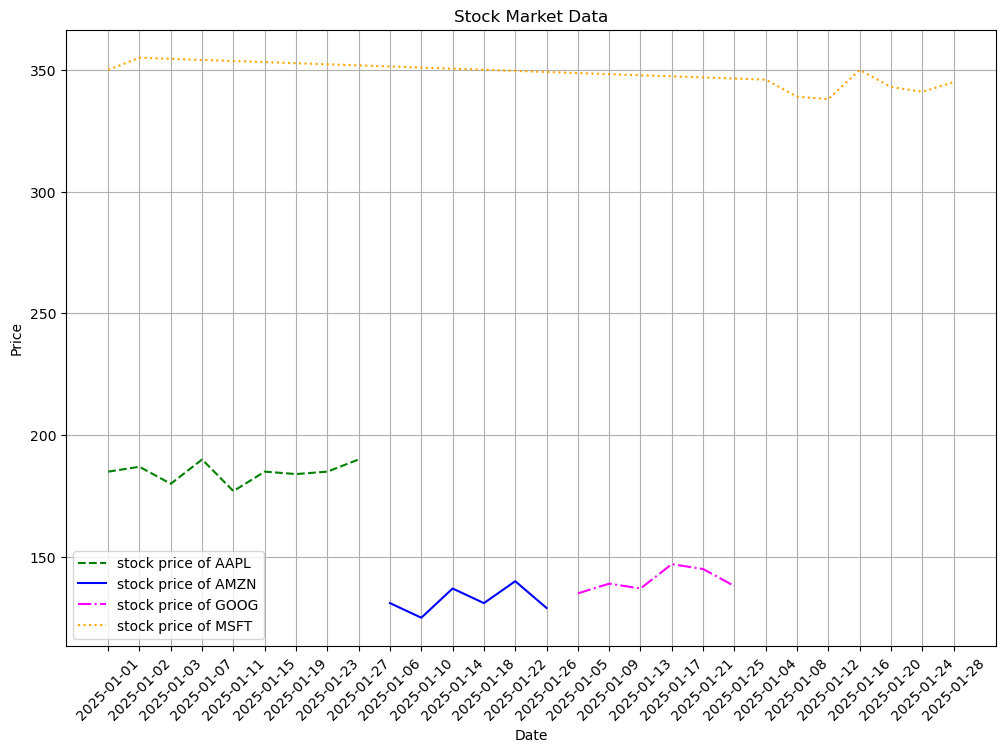

In [58]:
# create a color list
color_list = ["green","blue","magenta","orange"]
# create a linestyle_list
linestyle_list = ["--","-","-.",":"]

# create cyclic list using itertools
color_cycle = itertools.cycle(color_list)
linestyle_cycle = itertools.cycle(linestyle_list)

plt.figure(figsize=(12,8))
for stock, stock_df in groupby_stock_obj:
    plt.plot(stock_df["date"],stock_df["price"],color=next(color_cycle),linestyle=next(linestyle_cycle),label=f"stock price of {stock}")
plt.title("Stock Market Data")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

#### So what's happening here ?
```python
plt.plot(stock_df["date"], stock_df["price"], ...)
```
<br>

- Here I am plotting date(x-axis) vs price(y-axis).
- Since my DataFrame (```stock_df```) has multiple rows for each stock with different dates, matplotlib draws a continuous line for each stock across time.
- Grouping works as expected because within each group (```stock```), there's a time series (```date``` vs ```price```).
- But the key point is that this graph is not very useful

#### Let's try pivot method and reshape the dataFrame 

In [59]:
pivoted_stock_df = stock_df_original.pivot(index="date",columns="stock",values="price")
pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-01,185.0,NaN,NaN,350.0
2025-01-02,187.0,NaN,NaN,355.0
2025-01-03,180.0,NaN,NaN,NaN
2025-01-04,NaN,NaN,NaN,346.0
2025-01-05,NaN,NaN,135.0,NaN
2025-01-06,NaN,131.0,NaN,NaN
2025-01-07,190.0,NaN,NaN,NaN
2025-01-08,NaN,NaN,NaN,339.0
2025-01-09,NaN,NaN,139.0,NaN


#### Now Let's plot this data and see that we get 

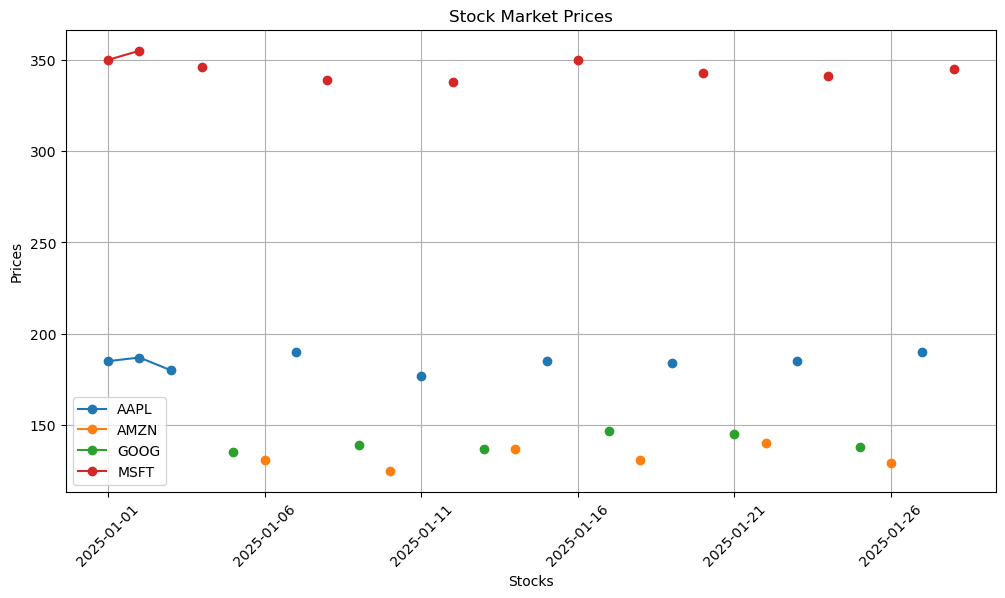

In [60]:
pivoted_stock_df.plot(marker="o",linestyle="-",figsize=(12,6))
plt.title("Stock Market Prices")
plt.xlabel("Stocks")
plt.ylabel("Prices")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

#### As you can see since the data is not clean we have to clean the data first to be able to make sense of this graph
- There is a lot of missing values that is present in the dataFrame after pivoting process is completed.
- Since we are dealing with ```NaN``` values we have to interpolate the data using time interpolation method
- Reason I am chosing time interpolation method is because we have dates as index in this dataFrame.

#### First lets verify wheather the index in this dataFrame is of type datetime or not

In [63]:
pd.api.types.is_datetime64_any_dtype(pivoted_stock_df.index)

False

In [64]:
pivoted_stock_df.index.dtype

dtype('O')

#### This means the index is not of type datetime 
Since the index of this dataFrame ```pivoted_stock_df``` is not of type datetime. We have to convert it into the type datetime.

In [66]:
pivoted_stock_df.index = pd.to_datetime(pivoted_stock_df.index)

#### Let's verify if the index is of type datetime

In [67]:
pd.api.types.is_datetime64_any_dtype(pivoted_stock_df.index)

True

In [68]:
pivoted_stock_df.index.dtype

dtype('<M8[ns]')

#### Ok now that the index of this dataFrame ```pivoted_stock_df``` is of datetime type we can perform interpolation with time method

#### Convert colums that have values in string type numbers like this ```"64"``` to ```64```

In [70]:
converted_pivoted_stock_df = pivoted_stock_df.infer_objects(copy=False)
converted_pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-01,185.0,NaN,NaN,350.0
2025-01-02,187.0,NaN,NaN,355.0
2025-01-03,180.0,NaN,NaN,NaN
2025-01-04,NaN,NaN,NaN,346.0
2025-01-05,NaN,NaN,135.0,NaN
2025-01-06,NaN,131.0,NaN,NaN
2025-01-07,190.0,NaN,NaN,NaN
2025-01-08,NaN,NaN,NaN,339.0
2025-01-09,NaN,NaN,139.0,NaN


#### Performing time method interpolation on ```converted_pivoted_stock_df``` dataFrame

In [72]:
converted_pivoted_stock_df = converted_pivoted_stock_df.select_dtypes(include=["number"]).interpolate(method="time")
converted_pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-01,185.00,NaN,NaN,350.00
2025-01-02,187.00,NaN,NaN,355.00
2025-01-03,180.00,NaN,NaN,350.50
2025-01-04,182.50,NaN,NaN,346.00
2025-01-05,185.00,NaN,135.00,344.25
2025-01-06,187.50,131.00,136.00,342.50
2025-01-07,190.00,129.50,137.00,340.75
2025-01-08,186.75,128.00,138.00,339.00
2025-01-09,183.50,126.50,139.00,338.75


#### So the in the resultant dataFrame has ```NaN``` values from dates ```2025-01-01``` to ```2025-01-05```
The reason why this happened because the ```.interpolate()``` function needs a starting and ending data to guess the data in between them, since the starting data in columns ```AMZN``` and ```GOOG``` was missing the ```.interpolate()``` function could not guess the missing data.

#### I am going to remove these rows which have NaN values in them
- Another way to handle NaN values in the dataFrame is using ```bfill``` and ```fillna```. In this I could have used ```bfill``` function to carry forward the data from the rows below. But I choose not to do that. 
- The reason, I can't use ```bfill``` (This function carry forward the data to the row which has NaN value from the row just next to it) because in case of stock prices more than two days the stock prices cannot be same in real world senarios i.e It may happen but changes of that happening is next to zero.
- **Notice** : The ```.pivot()``` function requires the data to be clean and tidy for it to work properly so I have to deal with NaN values in the dataFrame and clean the data in it for pivot to work properly. 
- This is why I have decided to remove the rows that have NaN values in them

In [74]:
cleaned_converted_pivoted_stock_df = converted_pivoted_stock_df.dropna()
cleaned_converted_pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-06,187.50,131.00,136.00,342.50
2025-01-07,190.00,129.50,137.00,340.75
2025-01-08,186.75,128.00,138.00,339.00
2025-01-09,183.50,126.50,139.00,338.75
2025-01-10,180.25,125.00,138.50,338.50
2025-01-11,177.00,128.00,138.00,338.25
2025-01-12,179.00,131.00,137.50,338.00
2025-01-13,181.00,134.00,137.00,341.00
2025-01-14,183.00,137.00,139.50,344.00


In [ ]:
#### 